In [1]:
# Import the required libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Load the RFM data
rfm = pd.read_pickle("../data/processed/rfm.pkl")

In [3]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,Segment
CustomerID,,,,,,,,
12346.0,326,12,77556.46,2,4,4,10,High Value
12347.0,2,8,4921.53,4,4,4,12,High Value
12348.0,75,5,2019.40,3,3,3,9,Medium Value
12349.0,19,4,4428.69,4,3,4,11,High Value
12350.0,310,1,334.40,2,1,1,4,Low Value


### Check the RFM data before ML

In [4]:
rfm[["Recency", "Frequency", "Monetary"]].describe().round(1)

,Recency,Frequency,Monetary
count,5878.0,5878.0,5878.0
mean,201.3,6.3,2955.9
std,209.3,13.0,14440.9
min,1.0,1.0,3.0
25%,26.0,1.0,342.3
50%,96.0,3.0,867.7
75%,380.0,7.0,2248.3
max,739.0,398.0,580987.0


### Select the features

In [5]:
features = rfm[["Recency", "Frequency", "Monetary"]]

### Standardize the features

In [6]:
scaler = StandardScaler()

In [7]:
scaled_features = scaler.fit_transform(features)

In [8]:
scaled_features[:5]

array([[ 0.59558355,  0.43899789,  5.16637792],
       [-0.95227909,  0.13150188,  0.13612722],
       [-0.60353226, -0.09912012, -0.06485654],
       [-0.87106408, -0.17599412,  0.10199614],
       [ 0.51914589, -0.40661612, -0.18154933]])

### Create the K-Means model

In [9]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

### Fit K-Means and assign clusters

In [13]:
rfm["Cluster"] = kmeans.fit_predict(scaled_features)

### Analyze the clusters

In [12]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("Recency", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean")
).round(1)

cluster_summary

,Customers,AvgRecency,AvgFrequency,AvgMonetary
Cluster,,,,
0,3847,66.3,7.6,3136.1
1,2009,461.9,2.2,747.3
2,22,23.1,143.0,173123.6


### Rename the clusters

In [14]:
cluster_order = (
    cluster_summary
    .sort_values("AvgMonetary", ascending=False)
    .index
)

In [15]:
cluster_names = {
    cluster_order[0]: "Best Customers",
    cluster_order[1]: "Regular Customers",
    cluster_order[2]: "Occasional Customers"
}

In [16]:
rfm["ClusterName"] = rfm["Cluster"].map(cluster_names)

In [19]:
# Check the number of customers in each cluster
print("--- Customers per Cluster ---")
print(rfm["ClusterName"].value_counts())

--- Customers per Cluster ---
ClusterName
Regular Customers       3847
Occasional Customers    2009
Best Customers            22
Name: count, dtype: int64


### Create a cluster visualization

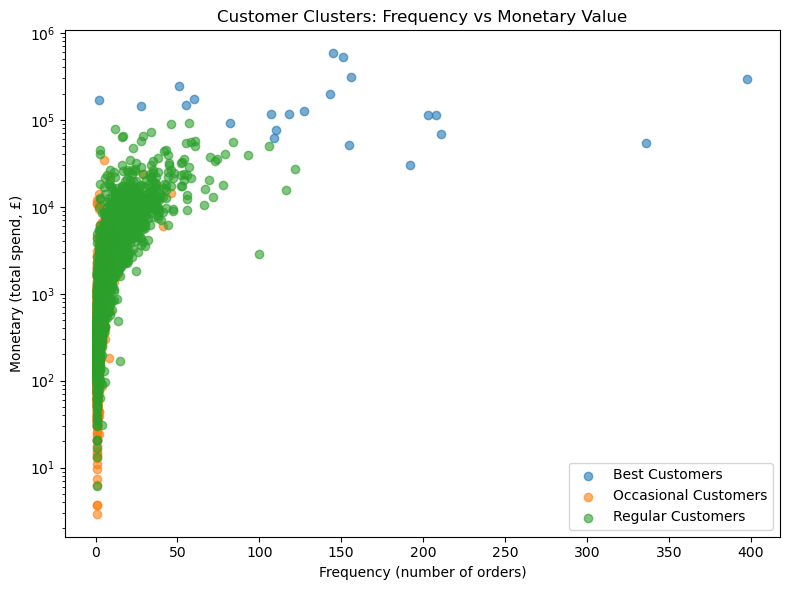

In [20]:
plt.figure(figsize=(8, 6))

for name, group in rfm.groupby("ClusterName"):
    plt.scatter(
        group["Frequency"],
        group["Monetary"],
        label=name,
        alpha=0.6
    )

plt.xlabel("Frequency (number of orders)")
plt.ylabel("Monetary (total spend, £)")
plt.yscale("log")
plt.title("Customer Clusters: Frequency vs Monetary Value")
plt.legend()
plt.tight_layout()
plt.show()

### Save the final clustered dataset

In [21]:
rfm.to_pickle("../data/processed/rfm_clustered.pkl")